# 对汽车是否值得购买，进行聚类分析
1、数据指标解释：

* buying, 购买费用
* maint, 维修费用
* doors, 车门数量
* person, 乘坐人数
* lug_boot, 行李箱容量
* safety,  安全性

2、对数据进行转换

* 将字符串转换映射量化为数字



3、使用DBSCAN和分层聚类算法进行聚类

* 调整参数，寻找最佳效果（轮廓系数值最大）
## 导入库

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.datasets import make_blobs 
from sklearn.metrics import silhouette_score


## 加载数据

In [2]:
raw_data=pd.read_csv("./data/inputs/car_data.csv")
raw_data.head()

,buying,maint,doors,person,lug_boot,safety
0,vhigh,2,2,small,low,unacc
1,vhigh,2,2,small,med,unacc
2,vhigh,2,2,small,high,unacc
3,vhigh,2,2,med,low,unacc
4,vhigh,2,2,med,med,unacc


In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   person    1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
dtypes: object(6)
memory usage: 81.1+ KB


In [4]:
print("数据维度：",raw_data.shape)
print("null vlues：",raw_data.isnull().sum())
raw_data.describe()

数据维度： (1728, 6)
null vlues： buying      0
maint       0
doors       0
person      0
lug_boot    0
safety      0
dtype: int64


,buying,maint,doors,person,lug_boot,safety
count,1728,1728,1728,1728,1728,1728
unique,4,4,3,3,3,4
top,vhigh,2,2,small,low,unacc
freq,432,432,576,576,576,1210


## 数据预处理

In [5]:
unique_map = {col: raw_data[col].unique().tolist() for col in raw_data.columns}
print(unique_map)

{'buying': ['vhigh', 'high', 'med', 'low'], 'maint': ['2', '3', '4', '5more'], 'doors': ['2', '4', 'more'], 'person': ['small', 'med', 'big'], 'lug_boot': ['low', 'med', 'high'], 'safety': ['unacc', 'acc', 'vgood', 'good']}


In [6]:
data=raw_data.reset_index(drop=True)
data["buying"]=data["buying"].map({"vhigh":1,"high":2,"med":3,"low":4})
data["maint"]=data["maint"].map({"2":2,"3":3,"4":4,"5more":5})
data["doors"]=data["doors"].map({"2":2,"4":4,"more":5})
data["person"]=data["person"].map({"small":2,"med":5,"big":7})
data["lug_boot"]=data["lug_boot"].map({"low":1,"med":2,"high":3})
data["safety"]=data["safety"].map({"unacc":1,"acc":2,"good":3,"vgood":4})


In [7]:
data.head()

,buying,maint,doors,person,lug_boot,safety
0,1,2,2,2,1,1
1,1,2,2,2,2,1
2,1,2,2,2,3,1
3,1,2,2,5,1,1
4,1,2,2,5,2,1


## 建模
### kmeans

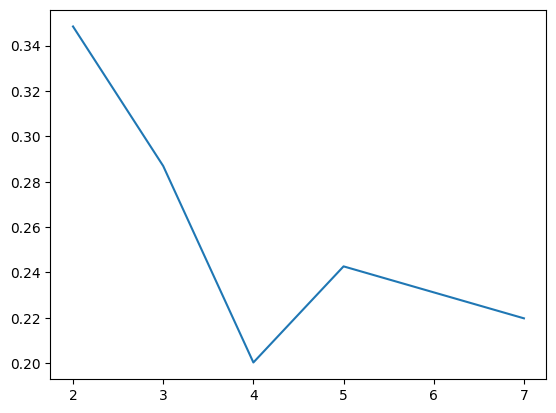

In [8]:
X=data
scores=[]# best_n_clusters=6
for k in range(2,8):
    kmeans=KMeans(n_clusters=k)
    y_=kmeans.fit_predict(X) 
    score=silhouette_score(X,y_)
    scores.append(score)
plt.plot(range(2,8),scores)

In [9]:
kmeans=KMeans(n_clusters=6)
y_=kmeans.fit_predict(X)
print('得分是：',silhouette_score(X,y_))
np.unique(y_)

得分是： 0.23274893394191065


array([0, 1, 2, 3, 4, 5], dtype=int32)

### DBCAN

In [13]:
score_high=0
best_params={}
eps=np.linspace(0.1,1,10).tolist()
min_samples=list(range(3,10,2))
for i in eps:
    for j in min_samples:
        dbscan = DBSCAN(eps = i,min_samples = j)
        y_ = dbscan.fit_predict(X)
        unique_labels = set(y_)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
            
        if n_clusters >= 2:
            score = silhouette_score(X,y_)
            if score > score_high:
                best_params.clear()
                score_high = score
                best_params['best'] = {'eps':i,'min_samples':j}
print('最高分：',score_high)
print(best_params)


最高分： 0.49579210730561935
{'best': {'eps': 0.1, 'min_samples': 3}}


In [14]:
dbscan = DBSCAN(eps = 0.1,min_samples = 3)
y_ = dbscan.fit_predict(X)
print('得分是：',silhouette_score(X,y_))
np.unique(y_)

得分是： 0.49579210730561935


array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 17

In [16]:
X.shape

(1728, 6)

### 分层聚类

In [17]:
score_high = 0
best_params = {}
n_clusters = range(2,10)
linkage = ['ward', 'complete', 'average', 'single']
for i in n_clusters:
    for j in linkage:  
        agg = AgglomerativeClustering(n_clusters=i,linkage=j)
        y_ = agg.fit_predict(X)
        if score > score_high:
            score_high = score
            best_params.clear()
            best_params['best'] = {'n_clusters':i,'linkage':j}
print(score_high)
print(best_params)

0.21086710181993254
{'best': {'n_clusters': 2, 'linkage': 'ward'}}


In [18]:
agg = AgglomerativeClustering(n_clusters=2,linkage='ward')
y_ = agg.fit_predict(X)
y_

array([1, 1, 1, ..., 0, 0, 0], shape=(1728,))